# PNEUMONIA DETECTION SYSTEM 


In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import ResNet101V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D,
    Dense, Dropout, LayerNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [3]:
# BASE_DIR = "/content/drive/MyDrive/Dataset"
BASE_DIR=os.path.join("Dataset")

RAW_TRAIN_DIR = os.path.join(BASE_DIR, "train")

TRAIN_SPLIT_DIR = os.path.join(BASE_DIR, "train_split")
VAL_SPLIT_DIR   = os.path.join(BASE_DIR, "valid_split")
TEST_SPLIT_DIR  = os.path.join(BASE_DIR, "test_split")

CLASSES = ["NORMAL", "PNEUMONIA"]

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


In [4]:
print(os.listdir(RAW_TRAIN_DIR))


['NORMAL', 'PNEUMONIA']


In [5]:
splits_exist = (
    os.path.exists(TRAIN_SPLIT_DIR) and
    os.path.exists(VAL_SPLIT_DIR) and
    os.path.exists(TEST_SPLIT_DIR)
)

if splits_exist:
    print("Using existing dataset splits")

else:
    print("Creating 70 / 15 / 15 dataset split")

    for split_dir in [TRAIN_SPLIT_DIR, VAL_SPLIT_DIR, TEST_SPLIT_DIR]:
        for cls in CLASSES:
            os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

    for cls in CLASSES:
        src_dir = os.path.join(RAW_TRAIN_DIR, cls)
        images = os.listdir(src_dir)
        random.shuffle(images)

        total = len(images)
        train_end = int(0.7 * total)
        val_end   = int(0.85 * total)

        train_imgs = images[:train_end]
        val_imgs   = images[train_end:val_end]
        test_imgs  = images[val_end:]

        for img in train_imgs:
            shutil.copy(os.path.join(src_dir, img),
                        os.path.join(TRAIN_SPLIT_DIR, cls, img))

        for img in val_imgs:
            shutil.copy(os.path.join(src_dir, img),
                        os.path.join(VAL_SPLIT_DIR, cls, img))

        for img in test_imgs:
            shutil.copy(os.path.join(src_dir, img),
                        os.path.join(TEST_SPLIT_DIR, cls, img))


Using existing dataset splits


In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    # zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_SPLIT_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_SPLIT_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_SPLIT_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 2724 images belonging to 2 classes.
Found 835 images belonging to 2 classes.
Found 838 images belonging to 2 classes.


In [8]:
base_model = ResNet101V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

inputs = Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet_v2.preprocess_input(inputs)
x = base_model(x)

x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="swish")(x)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, activation="swish")(x)
x = LayerNormalization()(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101v2 (Functional)        │ (None, 7, 7, 2048)     │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 512)            │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,808,769 (167.12 MB)

 Trainable params: 16,416,257 (62.62 MB)

 Non-trainable params: 27,392,512 (104.49 MB)

In [9]:
from tensorflow.keras import optimizers
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)


class_weight_dict = dict(enumerate(class_weights_array))

print(f"Applying class weights: {class_weight_dict}")


history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,       
    callbacks=callbacks, 
    class_weight=class_weight_dict,  
    verbose=1            
)

Applying class weights: {0: np.float64(1.8497292418772564), 1: np.float64(0.6852223336676697)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8082 - loss: 0.4630 - precision: 0.9120 - recall: 0.8221 - val_accuracy: 0.2882 - val_loss: 1.0219 - val_precision: 1.0000 - val_recall: 0.0250 - learning_rate: 3.0000e-05
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8949 - loss: 0.2644 - precision: 0.9635 - recall: 0.8892 - val_accuracy: 0.7961 - val_loss: 0.4556 - val_precision: 0.9657 - val_recall: 0.7473 - learning_rate: 3.0000e-05
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9088 - loss: 0.2409 - precision: 0.9704 - recall: 0.9019 - val_accuracy: 0.9191 - val_loss: 0.2049 - val_precision: 0.9657 - val_recall: 0.9220 - learning_rate: 3.0000e-05
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9020 - loss: 0.2381 - precision: 0.9638 - recall: 0.8989 - val_accuracy: 0.9419 - val_loss: 0.1531 - val_precision: 0.9567 - val_recall: 0.9641 - learning_rate: 3.0000e-05
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step -

## SAVING THE MODEL


In [ ]:
import os

folder_path = '/content/drive/My Drive/Saved model'
os.makedirs(folder_path, exist_ok=True)

model_path = os.path.join(folder_path, 'mymodel.keras')
model.save(model_path)


### Saving the model history

In [ ]:
import os
import json
import tensorflow as tf

folder_path = '/content/drive/My Drive/Output'

if not os.path.exists(folder_path):
    os.makedirs(folder_path)


history_dict = history.history


json_path = os.path.join(folder_path, 'training_history.json')

with open(json_path, 'w') as f:
    json.dump(history_dict, f,indent=4)

print(f"History saved successfully to: {json_path}")

History saved successfully to: /content/drive/My Drive/Output/training_history.json


## TRAINING GRAPHS


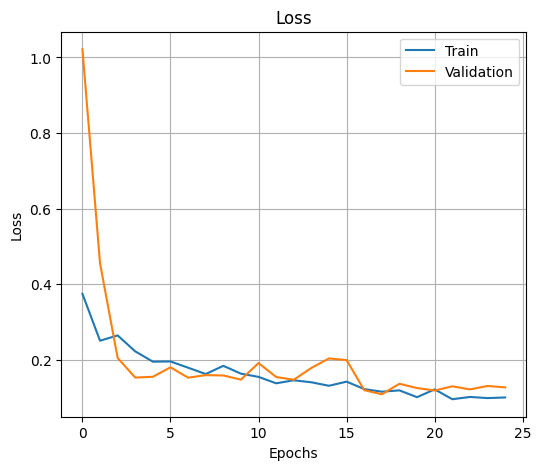

Saved: Output\Plots\loss.png


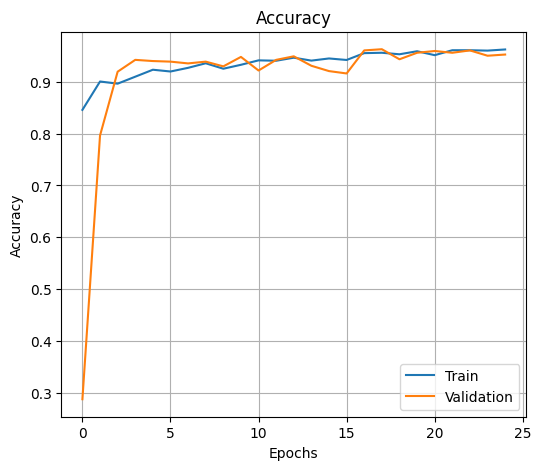

Saved: Output\Plots\accuracy.png


In [ ]:
import os
import json
import matplotlib.pyplot as plt


history_path =os.path.join("Output", "training_history.json")
plot_folder=os.path.join("Output","Plots")
os.makedirs(plot_folder, exist_ok=True)


with open(history_path, 'r') as f:
    history = json.load(f)

metrics = ["loss", "accuracy"]


for metric in metrics:
    plt.figure(figsize=(6, 5))
    plt.plot(history[metric], label="Train")
    plt.plot(history[f"val_{metric}"], label="Validation")

    plt.title(metric.capitalize())
    plt.xlabel("Epochs")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(plot_folder, f"{metric}.png")
    plt.savefig(save_path)
    plt.show()

    print(f"Saved: {save_path}")


## CONFUSION MATRIX

c:\Users\A S U S\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step


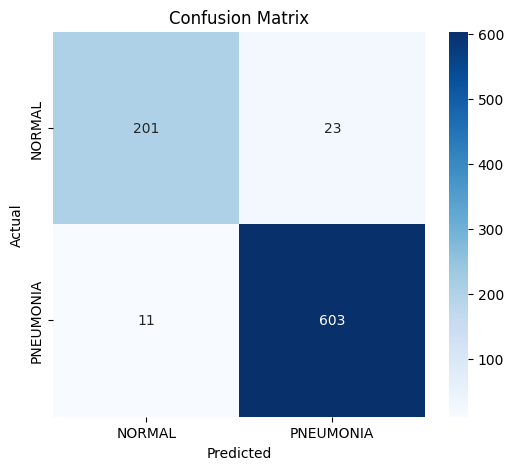

In [ ]:
import os
model_path=os.path.join("Saved model","mymodel.keras")
model=load_model(model_path)

y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype(int).flatten() 

y_true = test_gen.classes

save_dir =os.path.join("Output","Plots")
os.makedirs(save_dir, exist_ok=True)


cm = confusion_matrix(y_true, y_pred) 
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_path = os.path.join(save_dir, "confusion.png")
plt.savefig(save_path)
plt.show()




## CLASSIFICATION REPORT

In [ ]:
import os
save_dir =os.path.join("Output","Plots")
os.makedirs(save_dir, exist_ok=True)
report = classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys()),
    digits=4
)
report_path = os.path.join(save_dir, "classification.txt")
with open(report_path, "w") as f:
    f.write(report)

print("Saved")
print(report)


Saved
              precision    recall  f1-score   support

      NORMAL     0.9481    0.8973    0.9220       224
   PNEUMONIA     0.9633    0.9821    0.9726       614

    accuracy                         0.9594       838
   macro avg     0.9557    0.9397    0.9473       838
weighted avg     0.9592    0.9594    0.9591       838

